# Accuracy Model with Fixed Kepler Data - updated 2026-04-06
re-check the accuracy model process to see if:


- One regression model captures accuracy across a range of span lengths (100ms to 1000ms was what I did before)
- The rule of thumb of four measurements per span still gives us decent accuracy (better than 20% accuracy compared to the median "ground truth"). This should aid us also having a simple overhead model since I think four measurements "costs" the same every time?


I'm expecting nothing will challenge what we found before but we'll see!

# import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import statsmodels.api as sm

from scipy import stats
from scipy.stats import ks_2samp


sns.set_theme(style="whitegrid")

fs=24

## Import data

In [3]:
df_spans_100 = pd.read_csv("../../../Data/E2EGHG/span_100.csv")

In [4]:
df_spans_100

,trace.id,span.id,measurements.count,start_time_us,energy.joules,start.energy.joules,end.energy.joules,kepler.duration.ms,kepler.energy.joules,exper_name,cpu_ms,active_interval_ms,concurrency
0,b55fbcb36fb51afe2a483a5f04d4b8aa,e525ba7d73a881c6,2,1775500636852892,9.639194,8749.308003,8751.051956,71,0,uniform-a,100,100,1.0
1,4403ddf5325cb53c0e451f94b8ec8279,90841a7ca4556c5c,2,1775500638832811,8.312817,8773.632395,8778.854780,88,0,uniform-a,100,100,1.0
2,0d48f22fee0e219dedfdf8d0bda3cc71,6242da915129d13c,2,1775500589293260,23.762205,8017.279370,8020.146139,68,0,uniform-a,100,100,1.0
3,2f47d1c294590b2ebc8db0da87a9bea1,7762e49472889070,2,1775500626939889,7.138222,8594.143108,8599.486104,63,0,uniform-a,100,100,1.0
4,e03154bd28c74467889102d9e2de1c75,c39fece67e4ab70a,2,1775500624960369,13.702599,8575.551997,8579.639062,95,0,uniform-a,100,100,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3793,9ca72d1133c229fe3f23ff5a2994ee55,64956aa87e1357f4,6,1775502811377451,32.921024,52542.708540,52572.792980,256,0,uniform-a,500,62,1.0
3794,b5999f0c4b13bf706f5356fa1058cbe5,c8cffb009df54437,6,1775502776676664,23.922667,51473.605070,51492.206681,189,0,uniform-a,500,62,1.0
3795,d6d2639e42722d2956c26c031d8dfea3,80b2a9ae776a3ffa,6,1775502806415815,29.852701,52388.012865,52411.703807,272,0,uniform-a,500,62,1.0
3796,584e1b1a7113ef4901ec45ec3ef9fcd2,e7c5e9c20486645b,6,1775502757848282,40.965588,50811.547012,50840.908027,285,0,uniform-a,500,62,1.0


In [5]:
df_spans_100.columns

Index(['trace.id', 'span.id', 'measurements.count', 'start_time_us',
       'energy.joules', 'start.energy.joules', 'end.energy.joules',
       'kepler.duration.ms', 'kepler.energy.joules', 'exper_name', 'cpu_ms',
       'active_interval_ms', 'concurrency'],
      dtype='str')

In [6]:
# replace . with _ in column names
df_spans_100.columns = df_spans_100.columns.str.replace('.', '_')
df_spans_100.columns

Index(['trace_id', 'span_id', 'measurements_count', 'start_time_us',
       'energy_joules', 'start_energy_joules', 'end_energy_joules',
       'kepler_duration_ms', 'kepler_energy_joules', 'exper_name', 'cpu_ms',
       'active_interval_ms', 'concurrency'],
      dtype='str')

In [8]:
# create reduced dataset for modeling
df = df_spans_100.drop([ 'trace_id', 'measurements_count', 'start_time_us','start_energy_joules', 'end_energy_joules',
       'kepler_duration_ms', 'kepler_energy_joules', 'exper_name'], axis=1)
df.head(10)

,span_id,energy_joules,cpu_ms,active_interval_ms,concurrency
0,e525ba7d73a881c6,9.639194,100,100,1.0
1,90841a7ca4556c5c,8.312817,100,100,1.0
2,6242da915129d13c,23.762205,100,100,1.0
3,7762e49472889070,7.138222,100,100,1.0
4,c39fece67e4ab70a,13.702599,100,100,1.0
5,2f9e96e95951972d,8.068723,100,100,1.0
6,418d16ab31fd445e,7.828536,100,100,1.0
7,c11cbf648f2fc163,19.482032,100,100,1.0
8,e7b5d41e3781834b,13.679610,100,100,1.0
9,13621180bae57871,12.406953,100,100,1.0


#### filter out rows with too short active_interval_ms (< 25.0 ms are removed)

In [51]:
# df = df.query('active_interval_ms >= 25.0')
# df

### Get Median E for each cpu_ms

In [9]:
df_median_e_cpu = df[['energy_joules','cpu_ms']].copy()
df_median_e_cpu = df_median_e_cpu.groupby(['cpu_ms'], as_index=False).median()
df_median_e_cpu

,cpu_ms,energy_joules
0,50,11.171038
1,100,13.749231
2,150,16.708604
3,200,20.031592
4,250,22.957839
5,500,37.107013
6,1000,62.757050
7,2000,135.534067


### add column with median energy for that cpu_ms to each trace_id

In [10]:
cpu_ms_vals = np.unique(df['cpu_ms'])
for i in cpu_ms_vals:
    df.loc[df['cpu_ms'] == i, 'median_energy_cpu_ms'] = df_median_e_cpu[df_median_e_cpu['cpu_ms'] == i].energy_joules.values[0]

df.head(10)

,span_id,energy_joules,cpu_ms,active_interval_ms,concurrency,median_energy_cpu_ms
0,e525ba7d73a881c6,9.639194,100,100,1.0,13.749231
1,90841a7ca4556c5c,8.312817,100,100,1.0,13.749231
2,6242da915129d13c,23.762205,100,100,1.0,13.749231
3,7762e49472889070,7.138222,100,100,1.0,13.749231
4,c39fece67e4ab70a,13.702599,100,100,1.0,13.749231
5,2f9e96e95951972d,8.068723,100,100,1.0,13.749231
6,418d16ab31fd445e,7.828536,100,100,1.0,13.749231
7,c11cbf648f2fc163,19.482032,100,100,1.0,13.749231
8,e7b5d41e3781834b,13.679610,100,100,1.0,13.749231
9,13621180bae57871,12.406953,100,100,1.0,13.749231


Text(0, 0.5, 'Energy')

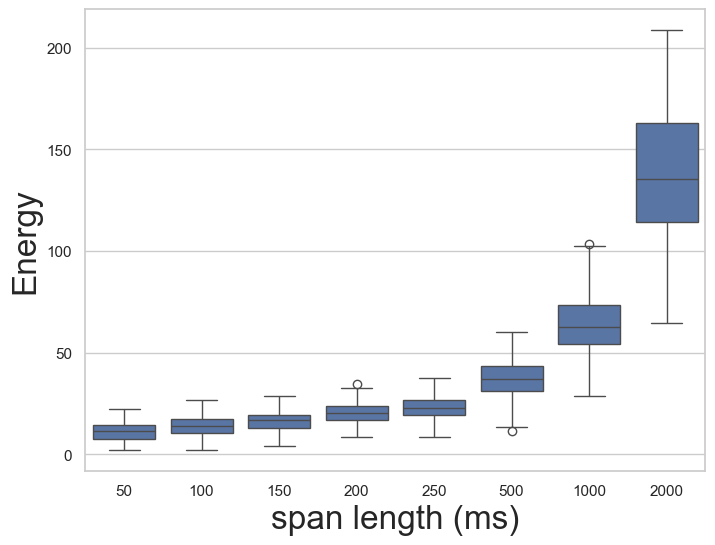

In [11]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='cpu_ms', y='energy_joules')#, col='cpu_ms', col_wrap=4, palette='tab10', markers='o', ci=95)
plt.xlabel("span length (ms)", fontsize=fs)
plt.ylabel(r'Energy', fontsize=fs)

### From the "Taming Performance Variability" paper: "compute $\lfloor{\frac{n - z \sqrt{n}}{ 2}}\rfloor$ and $\lceil{1+\frac{n+z \sqrt{n}  }{2} }\rceil$,where n is the number of elements in X, and z is the standard score (or z-score). z depends only on the desired confidence level, and is 1.96 for the commonly-used level of $\alpha = 95\\\%$. These two numbers are then used as indexes into the sorted X: the values at those locations are the top and the bottom bounds of the CI. Note that one of these numbers will be larger than the median (at index n/2) and the other will be smaller, and they will not necessarily be symmetric around the median. These bounds tend to get tighter—to approach the sample mean—with more repetitions. Typically, we are concerned with the relative difference r% between the CI bounds and the mean."

In [7]:
# df['gender'] = df['gender'].apply(lambda x: 0 if x == 'female' else x)

#df_filtered_1000_fixed['sampling_ratio'] = df_filtered_1000_fixed['sampling_ratio'].apply(lambda x: 4.000000 if ((x > 4) & (x < 5)) else x)


#### Build confidence intervals on median Energy - note we are using all data for a span (all measurement frequencies)

In [12]:
# copy data for experimenting
df_test = df.copy()

In [13]:
span_lengths = np.unique(df_test.cpu_ms)
span_lengths

array([  50,  100,  150,  200,  250,  500, 1000, 2000])

In [14]:
# set params for conf intervals calculation
# here using the Z-score for 95% confidence

z = 1.96


temp_df = pd.DataFrame(columns=['n','cpu_ms','median_energy','e_upper_ci','e_lower_ci'])

for span_ms in span_lengths:
    the_n = df_test.query('(cpu_ms == @span_ms)').shape[0]
    lower_ci_idx = int(np.floor((the_n - z*np.sqrt(the_n))/2))
    upper_ci_idx = int(np.ceil(1 + ((the_n + z*np.sqrt(the_n))/2)))
    acc_eng = df_test.query('(cpu_ms == @span_ms)')['energy_joules']
    acc_eng_sorted = np.sort(acc_eng)
    acc_eng_upper_ci = acc_eng_sorted[upper_ci_idx]
    acc_eng_lower_ci = acc_eng_sorted[lower_ci_idx]
    temp_df.loc[len(temp_df.index)] = [the_n, span_ms, acc_eng.median(), acc_eng_upper_ci, acc_eng_lower_ci]
        #print(the_n,span_ms,ratio,acc_eng_upper_ci,acc_eng_lower_ci)

temp_df
        

,n,cpu_ms,median_energy,e_upper_ci,e_lower_ci
0,200.0,50.0,11.171038,11.951071,10.419871
1,300.0,100.0,13.749231,14.856791,13.064372
2,300.0,150.0,16.708604,16.978045,15.761901
3,400.0,200.0,20.031592,20.651829,19.530513
4,500.0,250.0,22.957839,23.731881,22.367382
5,600.0,500.0,37.107013,38.128331,36.245271
6,698.0,1000.0,62.757050,64.551659,60.922280
7,800.0,2000.0,135.534067,139.259195,133.305321


In [15]:
# save those energies and CIs for later
df_median_energy_with_ci = temp_df.copy()
df_median_energy_with_ci

,n,cpu_ms,median_energy,e_upper_ci,e_lower_ci
0,200.0,50.0,11.171038,11.951071,10.419871
1,300.0,100.0,13.749231,14.856791,13.064372
2,300.0,150.0,16.708604,16.978045,15.761901
3,400.0,200.0,20.031592,20.651829,19.530513
4,500.0,250.0,22.957839,23.731881,22.367382
5,600.0,500.0,37.107013,38.128331,36.245271
6,698.0,1000.0,62.757050,64.551659,60.922280
7,800.0,2000.0,135.534067,139.259195,133.305321


## Plot Median E with CIs

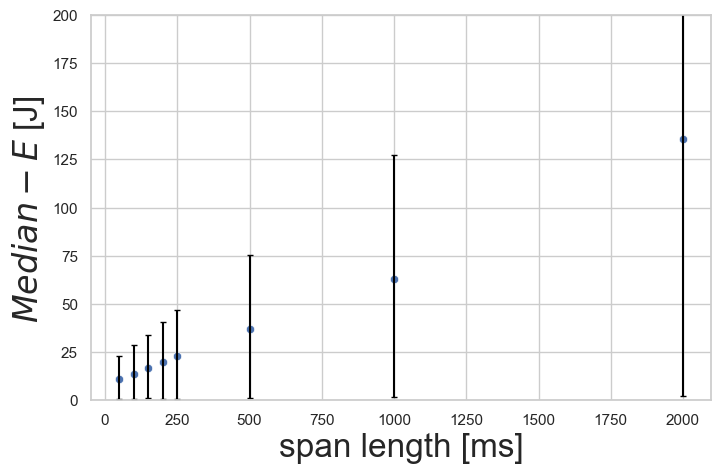

In [18]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=temp_df, x='cpu_ms', y='median_energy')
plt.errorbar(temp_df['cpu_ms'], temp_df['median_energy'], yerr=[temp_df['e_lower_ci'],temp_df['e_upper_ci'] ], fmt='none', capsize=2,color='black')
# plt.plot(x_vals, reg_model(x_vals), color="black", linestyle="--")
plt.ylim(0,200)
plt.xlabel("span length [ms]", fontsize=fs)
plt.ylabel(r'$Median-E$ [J] ', fontsize=fs)
#plt.title("cpu_ms = "+str(i)+" OLS model vs data")
plt.show()

## Back to Accuracy Modeling

In [19]:
df

,span_id,energy_joules,cpu_ms,active_interval_ms,concurrency,median_energy_cpu_ms
0,e525ba7d73a881c6,9.639194,100,100,1.0,13.749231
1,90841a7ca4556c5c,8.312817,100,100,1.0,13.749231
2,6242da915129d13c,23.762205,100,100,1.0,13.749231
3,7762e49472889070,7.138222,100,100,1.0,13.749231
4,c39fece67e4ab70a,13.702599,100,100,1.0,13.749231
...,...,...,...,...,...,...
3793,64956aa87e1357f4,32.921024,500,62,1.0,37.107013
3794,c8cffb009df54437,23.922667,500,62,1.0,37.107013
3795,80b2a9ae776a3ffa,29.852701,500,62,1.0,37.107013
3796,e7c5e9c20486645b,40.965588,500,62,1.0,37.107013


### calculate deviation per trace E from median for that cpu_ms

In [20]:
df['energy_devation'] = (df.median_energy_cpu_ms - df.energy_joules) 

### and add columns for % deviation from median for that cpu_ms, sampling ratio, and accuracy
#### an accuracy of 1.0 would mean it got the span mean energy value exactly for that trace

In [21]:
df['energy_deviation_pct'] = 100 * df.energy_devation / df.median_energy_cpu_ms
df['sampling_ratio'] = df.cpu_ms / df.active_interval_ms
df['energy_deviation_pct_abs'] = np.abs(df.energy_deviation_pct)

In [25]:
df


,span_id,energy_joules,cpu_ms,active_interval_ms,median_energy_cpu_ms,energy_devation,energy_deviation_pct,sampling_ratio,energy_deviation_pct_abs
0,0fba401994f44764,0.354891,100,100,0.358166,0.003275,0.914380,1.000000,0.914380
1,988e64c0db11f61f,0.285905,100,100,0.358166,0.072261,20.175282,1.000000,20.175282
2,f6200cba4a3fe9c7,0.330809,100,100,0.358166,0.027357,7.638078,1.000000,7.638078
3,eb258b6dab05d197,0.329298,100,100,0.358166,0.028868,8.059950,1.000000,8.059950
4,e71daf18301cd67e,0.392451,100,100,0.358166,-0.034285,-9.572377,1.000000,9.572377
...,...,...,...,...,...,...,...,...,...
18995,e3744c1b29b5645b,2.089440,500,62,1.984828,-0.104612,-5.270583,8.064516,5.270583
18996,6149e0ae385c4296,1.862854,500,62,1.984828,0.121974,6.145318,8.064516,6.145318
18997,e8cd3649e3f9421e,1.926418,500,62,1.984828,0.058410,2.942824,8.064516,2.942824
18998,3fd4bd202eff1ccf,1.879143,500,62,1.984828,0.105685,5.324643,8.064516,5.324643


In [22]:
# copy data to preserve original
df_filtered = df.copy()

#### In this data there are some with a sampling ratio very close to but not exactly 4 and 8. Going to merge those with values close to 4 with those with exactly 4, same for 8

In [23]:

df_filtered.query('(sampling_ratio > 4) & (sampling_ratio < 5)').sampling_ratio

1098    4.054054
1099    4.054054
1100    4.054054
1101    4.054054
1102    4.054054
          ...   
2993    4.032258
2994    4.032258
2995    4.032258
2996    4.032258
2997    4.032258
Name: sampling_ratio, Length: 200, dtype: float64

In [24]:
# df['gender'] = df['gender'].apply(lambda x: 0 if x == 'female' else x)

df_filtered['sampling_ratio'] = df_filtered['sampling_ratio'].apply(lambda x: 4.000000 if ((x > 4) & (x < 5)) else x)
df_filtered['sampling_ratio'] = df_filtered['sampling_ratio'].apply(lambda x: 8.000000 if ((x > 8) & (x < 9)) else x)

# update recip ratio
df_filtered['recip_sampling_ratio'] = 1 / df_filtered.sampling_ratio
df_filtered['sqrt_recip_sampling_ratio'] = np.sqrt(df_filtered['recip_sampling_ratio'])

print(np.unique(df_filtered['sqrt_recip_sampling_ratio']))
# check it
# df_filtered_1000_fixed.query('(sampling_ratio == 4) & (sampling_ratio < 5)').sampling_ratio.count()
# df_filtered_1000_fixed.groupby('sampling_ratio').size(), df_filtered_1000_fixed.groupby('recip_sampling_ratio').size()

[0.1118034  0.15811388 0.2236068  0.31622777 0.35355339 0.5
 0.70710678 1.        ]


#### Looks cleaned up - moving on to modeling

#### Rebuild dataframe of median accuracy values

In [25]:
df_median_dev = df_filtered.loc[:, ['cpu_ms','sampling_ratio','energy_deviation_pct_abs']].groupby(['cpu_ms','sampling_ratio'], as_index=False).median()
df_median_dev = df_median_dev.rename(columns={'cpu_ms':'cpu_ms','sampling_ratio':'sampling_ratio','energy_deviation_pct_abs':'median_energy_deviation'})
df_median_dev['recip_sampling_ratio'] = 1 / df_median_dev.sampling_ratio
df_median_dev['sqrt_recip_sampling_ratio'] = np.sqrt(df_median_dev['recip_sampling_ratio'])
df_median_dev

,cpu_ms,sampling_ratio,median_energy_deviation,recip_sampling_ratio,sqrt_recip_sampling_ratio
0,50,1.0,31.628753,1.0000,1.000000
1,50,2.0,31.969912,0.5000,0.707107
2,100,1.0,25.090538,1.0000,1.000000
3,100,2.0,27.362454,0.5000,0.707107
4,100,4.0,26.329491,0.2500,0.500000
5,150,1.0,22.720338,1.0000,1.000000
6,150,2.0,18.701370,0.5000,0.707107
7,150,4.0,17.025644,0.2500,0.500000
8,200,1.0,19.054167,1.0000,1.000000
9,200,2.0,18.169786,0.5000,0.707107


#### plot accuracy vs sampling ratio and recip sampling ratio

Text(1512.7647569444446, 0.5, '$Median ({\\Delta E})$ %')

<Figure size 1000x1000 with 0 Axes>

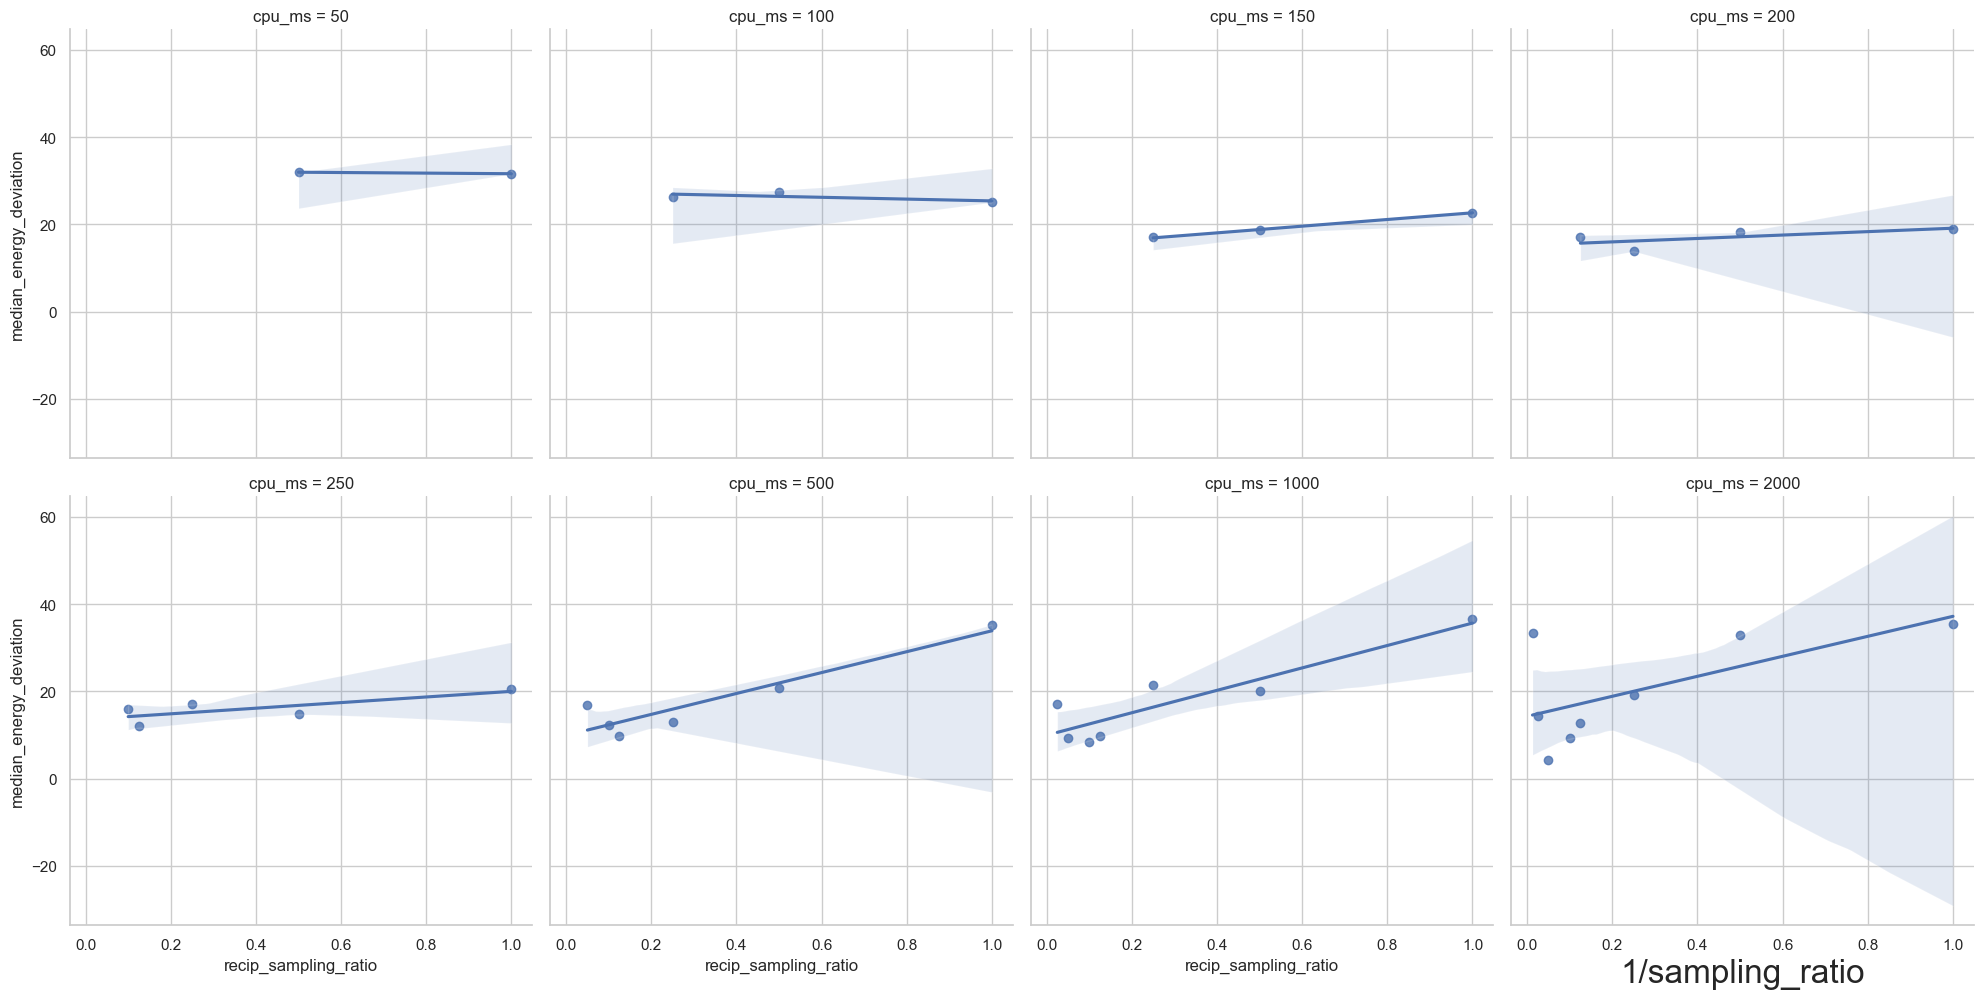

In [26]:
plt.figure(figsize=(10,10))
sns.lmplot(data=df_median_dev, x='recip_sampling_ratio', y='median_energy_deviation', col='cpu_ms', col_wrap=4, palette='tab10', markers='o', ci=95)
plt.xlabel("1/sampling_ratio", fontsize=fs)
plt.ylabel(r'$Median ({\Delta E})$ %', fontsize=fs)

Text(1512.7647569444446, 0.5, '$Median ({\\Delta E})$ %')

<Figure size 1000x1000 with 0 Axes>

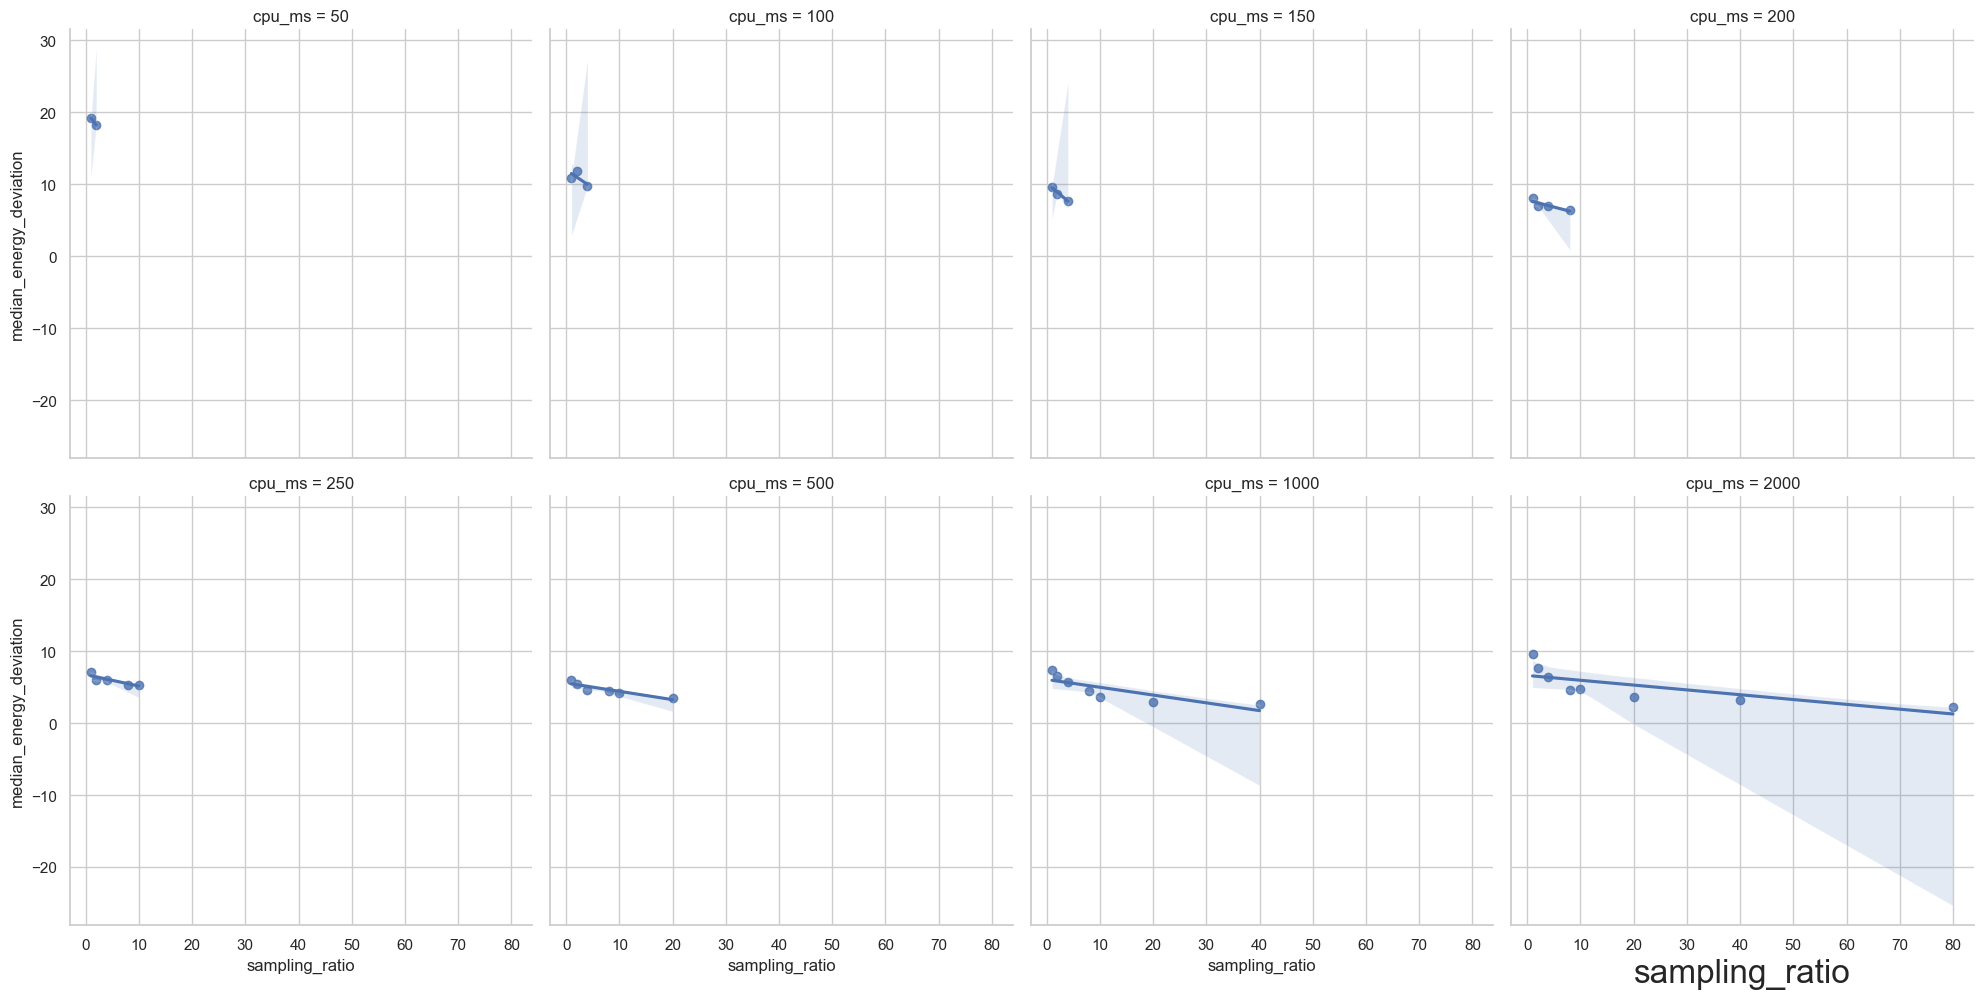

In [53]:
plt.figure(figsize=(10,10))
sns.lmplot(data=df_median_dev, x='sampling_ratio', y='median_energy_deviation', col='cpu_ms', col_wrap=4, palette='tab10', markers='o', ci=95)
plt.xlabel("sampling_ratio", fontsize=fs)
plt.ylabel(r'$Median ({\Delta E})$ %', fontsize=fs)

#### versus sqrt recip sampling ratio?

Text(1512.7647569444446, 0.5, '$Median ({\\Delta E})$ %')

<Figure size 1000x1000 with 0 Axes>

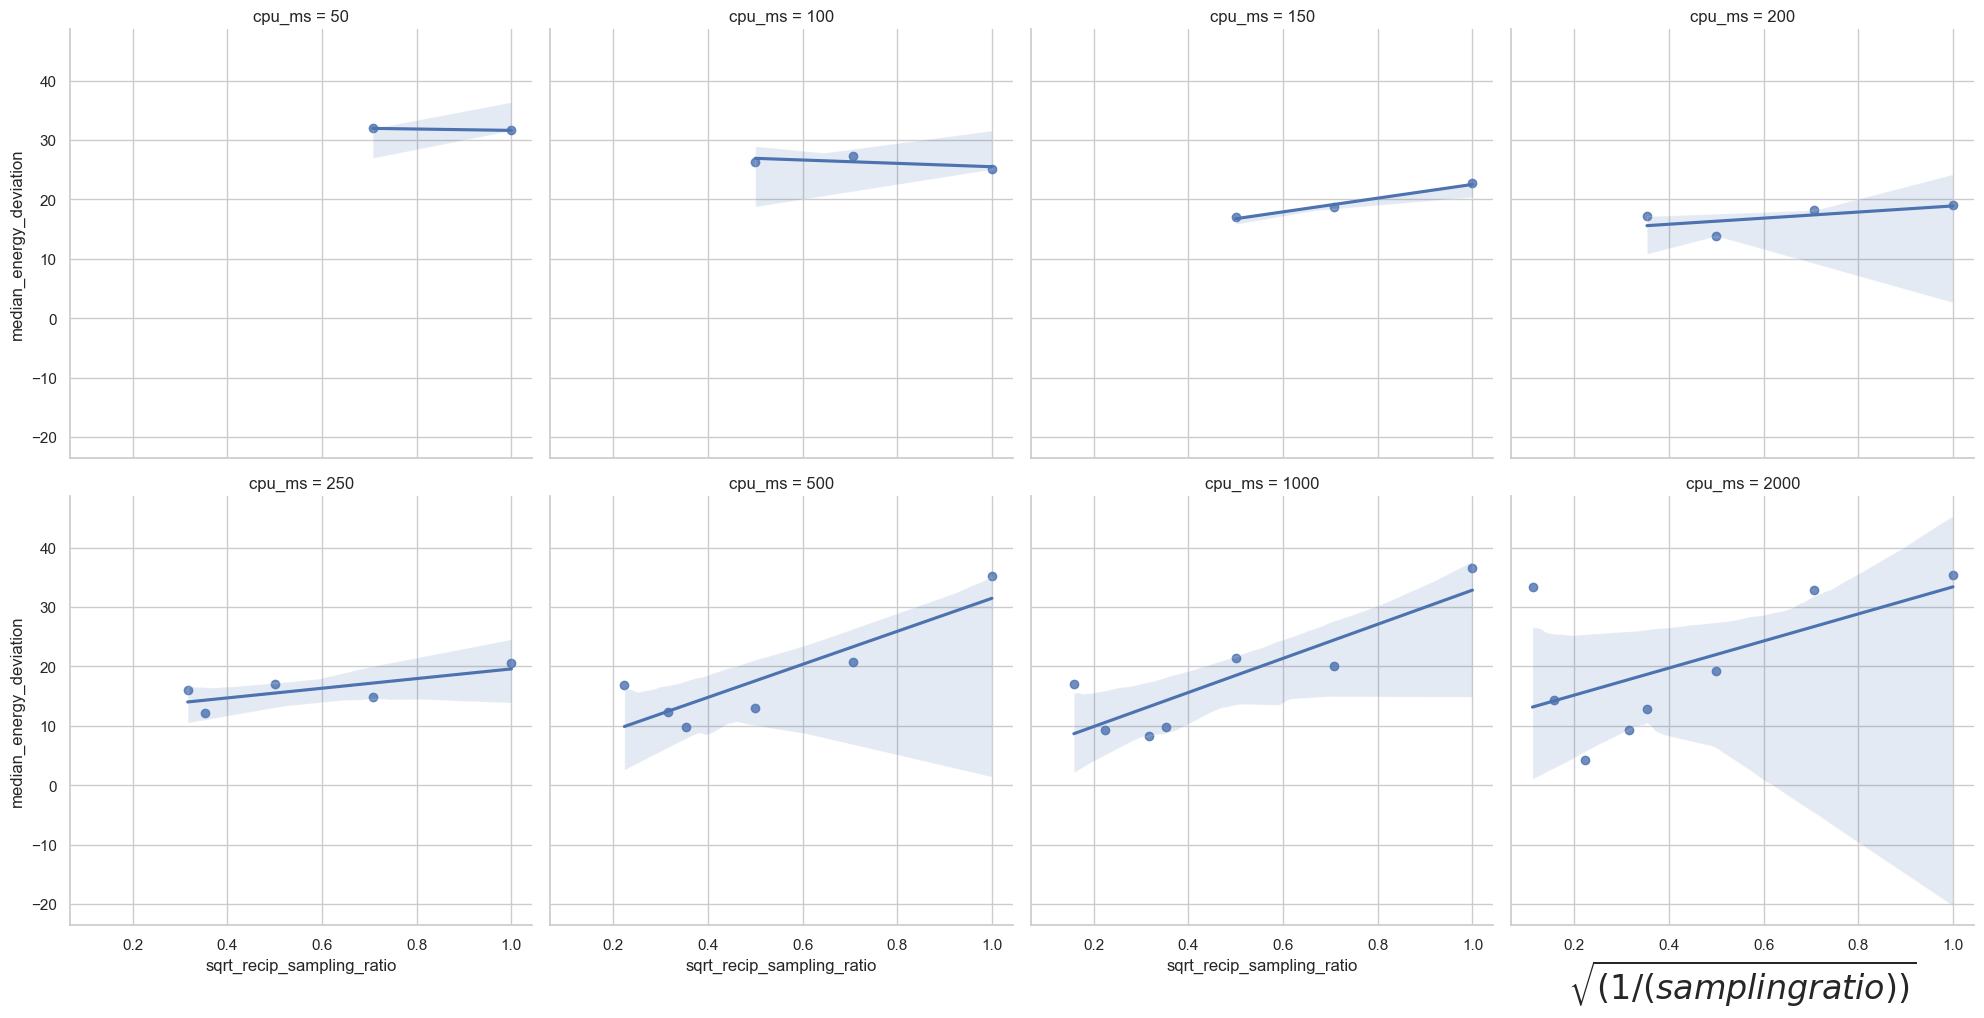

In [27]:
plt.figure(figsize=(10,10))
sns.lmplot(data=df_median_dev, x='sqrt_recip_sampling_ratio', y='median_energy_deviation', col='cpu_ms', col_wrap=4, palette='tab10', markers='o', ci=95)
plt.xlabel(r"$\sqrt{(1/(sampling ratio))}$", fontsize=fs)
plt.ylabel(r'$Median ({\Delta E})$ %', fontsize=fs)

## Accuracy vs SQRT(recip sampling ratio) is best!


#### Build confidence intervals on accuracy per span length and reciprocal sampling ratio

In [28]:
span_lengths = np.unique(df_median_dev.cpu_ms)
span_lengths

array([  50,  100,  150,  200,  250,  500, 1000, 2000])

In [29]:
# set params for conf intervals calculation
# here using the Z-score for 95% confidence

z = 1.96


temp_df = pd.DataFrame(columns=['n','cpu_ms','sqrt_recip_sampling_ratio','delta_e_upper_ci','delta_e_lower_ci'])

for span_ms in span_lengths:
    sqrt_ratio_list = np.unique(df_filtered.query('cpu_ms == @span_ms').sqrt_recip_sampling_ratio)
    for ratio in sqrt_ratio_list:
        the_n = df_filtered.query('(cpu_ms == @span_ms) & (sqrt_recip_sampling_ratio == @ratio)').shape[0]
        lower_ci_idx = int(np.floor((the_n - z*np.sqrt(the_n))/2))
        upper_ci_idx = int(np.ceil(1 + ((the_n + z*np.sqrt(the_n))/2)))
        acc_eng = df_filtered.query('(cpu_ms == @span_ms) & (sqrt_recip_sampling_ratio == @ratio)')['energy_deviation_pct_abs']
        acc_eng_sorted = np.sort(acc_eng)
        acc_eng_upper_ci = acc_eng_sorted[upper_ci_idx]
        acc_eng_lower_ci = acc_eng_sorted[lower_ci_idx]
        temp_df.loc[len(temp_df.index)] = [the_n, span_ms, ratio, acc_eng_upper_ci, acc_eng_lower_ci]
        #print(the_n,span_ms,ratio,acc_eng_upper_ci,acc_eng_lower_ci)

temp_df
        

,n,cpu_ms,sqrt_recip_sampling_ratio,delta_e_upper_ci,delta_e_lower_ci
0,100.0,50.0,0.707107,42.844389,22.386416
1,100.0,50.0,1.000000,36.122355,28.711226
2,100.0,100.0,0.500000,35.131638,20.571740
3,100.0,100.0,0.707107,32.192426,20.539360
4,100.0,100.0,1.000000,30.193761,17.733835
5,100.0,150.0,0.500000,25.747785,12.620465
6,100.0,150.0,0.707107,27.998535,15.164280
7,100.0,150.0,1.000000,30.052237,17.593256
8,100.0,200.0,0.353553,22.237061,12.574689
9,100.0,200.0,0.500000,19.086608,11.172449


### add columns with CI values for that cpu_ms and sampling ratio

In [30]:
cpu_ms_vals = np.unique(df_median_dev['cpu_ms'])
#ratio_vals = np.unique(df_median_dev_1000['recip_sampling_ratio'])

for i in cpu_ms_vals:
    ratio_vals = np.unique(df_median_dev.query('cpu_ms == @i').sqrt_recip_sampling_ratio)    
    for j in ratio_vals:
        # copy in CI values
        df_median_dev.loc[(df_median_dev['cpu_ms'] == i) & (df_median_dev['sqrt_recip_sampling_ratio'] == j), 
            'delta_e_upper_ci'] = temp_df[(temp_df['cpu_ms'] == i) & (temp_df['sqrt_recip_sampling_ratio'] == j)].delta_e_upper_ci.values[0]
        df_median_dev.loc[(df_median_dev['cpu_ms'] == i) & (df_median_dev['sqrt_recip_sampling_ratio'] == j), 
            'delta_e_lower_ci'] = temp_df[(temp_df['cpu_ms'] == i) & (temp_df['sqrt_recip_sampling_ratio'] == j)].delta_e_lower_ci.values[0]

df_median_dev.head(10)

,cpu_ms,sampling_ratio,median_energy_deviation,recip_sampling_ratio,sqrt_recip_sampling_ratio,delta_e_upper_ci,delta_e_lower_ci
0,50,1.0,31.628753,1.00,1.000000,36.122355,28.711226
1,50,2.0,31.969912,0.50,0.707107,42.844389,22.386416
2,100,1.0,25.090538,1.00,1.000000,30.193761,17.733835
3,100,2.0,27.362454,0.50,0.707107,32.192426,20.539360
4,100,4.0,26.329491,0.25,0.500000,35.131638,20.571740
5,150,1.0,22.720338,1.00,1.000000,30.052237,17.593256
6,150,2.0,18.701370,0.50,0.707107,27.998535,15.164280
7,150,4.0,17.025644,0.25,0.500000,25.747785,12.620465
8,200,1.0,19.054167,1.00,1.000000,22.810735,14.801921
9,200,2.0,18.169786,0.50,0.707107,22.474746,14.155258


#### now can use those CIs in plot of model performance

### generate linear model w/ sqrt(recip sampling ratio)

In [31]:
df_median_dev.columns

Index(['cpu_ms', 'sampling_ratio', 'median_energy_deviation',
       'recip_sampling_ratio', 'sqrt_recip_sampling_ratio', 'delta_e_upper_ci',
       'delta_e_lower_ci'],
      dtype='str')

#### All span lengths to 2000 ms

In [32]:
# # define x & y
# df_sub1000 = df_median_dev_1000.query("cpu_ms <= 1000.0")
X = df_median_dev.drop(['cpu_ms','sampling_ratio', 'median_energy_deviation',
       'recip_sampling_ratio','delta_e_upper_ci',
       'delta_e_lower_ci'], axis=1)
y = df_median_dev['median_energy_deviation']


#### do a train/test split of 80/20 so I can determine RMSE and $R^{2}$ on out-of-sample data

In [33]:
# create train/test split of data, 80/20 split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 47)

#### build model and check coefficients

In [34]:
mlr = LinearRegression()  
mlr.fit(x_train, y_train)
# output model coefficients
print("Coefficients: ", list(zip(X, mlr.coef_)), "\n Intercept: ", mlr.intercept_)

Coefficients:  [('sqrt_recip_sampling_ratio', np.float64(16.673577294013956))] 
 Intercept:  10.095522374846105


In [35]:
# make predictions based on test data
y_pred = mlr.predict(x_test)

In [36]:
# calculate rmse
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("The RMSE is: ", rmse)
print("The R^2 is: ", r2)

The RMSE is:  5.842091604179916
The R^2 is:  0.5512743293280917


#### Low RMSE relative to Energy and $R^{2} = 0.55$ is OK but not amazing - check plots

#### Plot some of the fits and original data

#### make function for using regression model in plot

In [37]:
# make function for using regression model
def reg_model(sqrt_recip_sampling_ratio):
    return (mlr.intercept_ + mlr.coef_[0]*sqrt_recip_sampling_ratio)

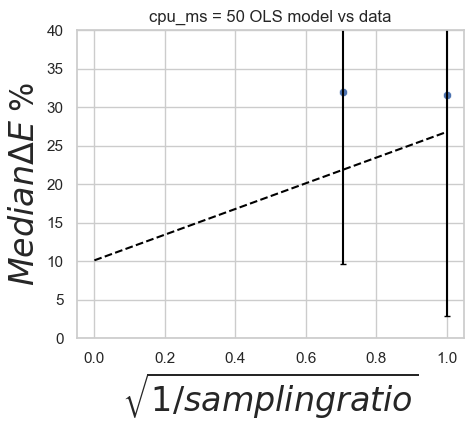

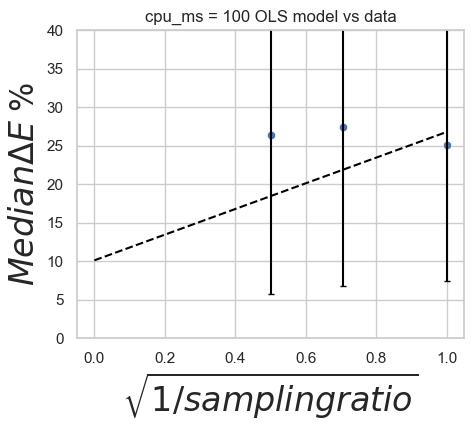

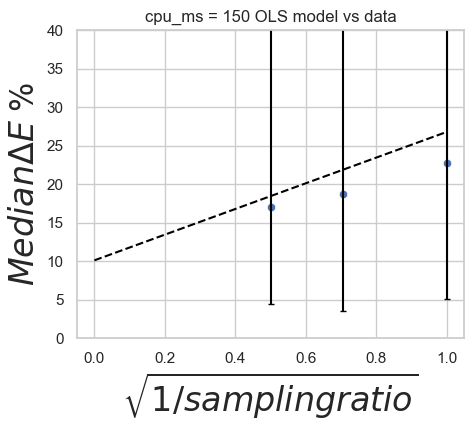

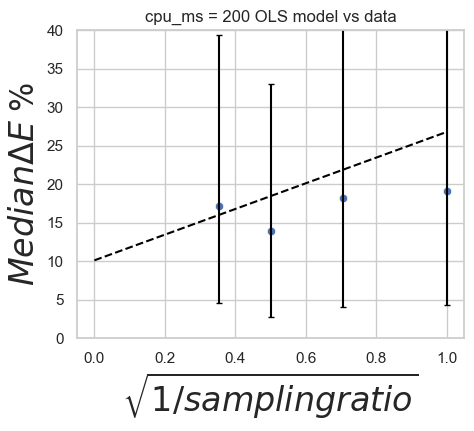

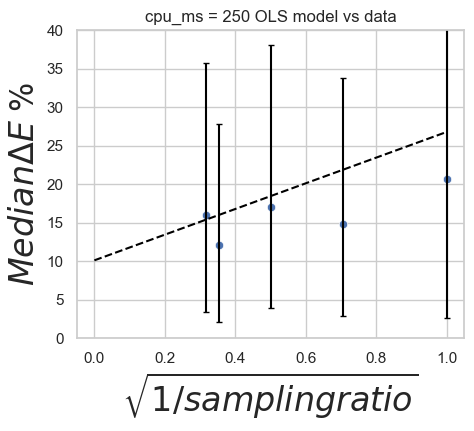

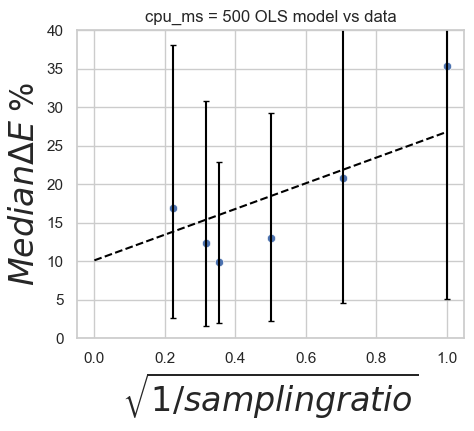

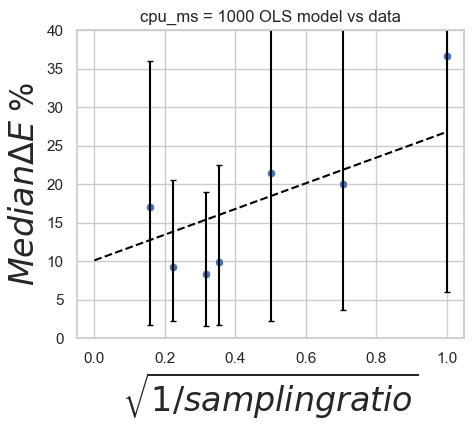

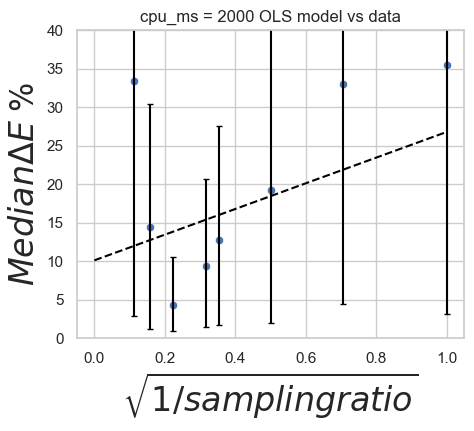

In [38]:
span_lengths = np.unique(df_median_dev.cpu_ms)

# range of recip_ratio values for plots
x_vals = np.arange(0,1.1,0.1)

# only up to 1000 ms spans
for i in span_lengths:
    tmp_df = df_median_dev.drop(['sampling_ratio','recip_sampling_ratio'], axis=1).query("cpu_ms == "+str(i))
    plt.figure(figsize=(5,4))
    sns.scatterplot(data=tmp_df, x=tmp_df['sqrt_recip_sampling_ratio'], y=tmp_df['median_energy_deviation'])
    plt.errorbar(tmp_df['sqrt_recip_sampling_ratio'], tmp_df['median_energy_deviation'], yerr=[tmp_df['delta_e_lower_ci'],tmp_df['delta_e_upper_ci'] ], fmt='none', capsize=2,color='black')
    plt.plot(x_vals, reg_model(x_vals), color="black", linestyle="--")
    plt.ylim(0,40)
    plt.xlabel(r"$\sqrt{1/samplingratio}$", fontsize=fs)
    plt.ylabel(r'$Median \Delta E$ %', fontsize=fs)
    plt.title("cpu_ms = "+str(i)+" OLS model vs data")
    plt.show()

In [39]:
print("Coefficients: ", list(zip(X, mlr.coef_)), "\n Intercept: ", mlr.intercept_)

Coefficients:  [('sqrt_recip_sampling_ratio', np.float64(16.673577294013956))] 
 Intercept:  10.095522374846105


### OLS model: $ Median Accuracy (\\\%) = 16.7*\sqrt{\frac{1}{sampling\\\_ratio}} + 10.1$
### where $sampling\\\_ratio = \frac{span_{ms}}{measurement\\\_interval_{ms}}$

### or: $ Median Accuracy (\\\%) = 16.7*\sqrt{ \frac{measurement\\\_interval_{ms}} {span_{ms}}} + 10.1$

## Thie data appears to show a minimum in deviation (best accuracy) for the longer spans whereas for shorter spans (< 200 ms) it looks fairly constant. Will need the larger data set to be certain